In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('../data/cleaned_heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
X = df.drop('target', axis=1)

y = df['target']

print(X.shape)
print(y.shape)

(297, 13)
(297,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(237, 13)
(60, 13)


In [6]:
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

logistic_pipeline.fit(X_train, y_train)

log_preds = logistic_pipeline.predict(X_test)

log_probs = logistic_pipeline.predict_proba(X_test)[:,1]

In [7]:
print('Logistic Regression Results')

print('Accuracy:', accuracy_score(y_test, log_preds))

print('Precision:', precision_score(y_test, log_preds))

print('Recall:', recall_score(y_test, log_preds))

print('F1 Score:', f1_score(y_test, log_preds))

print('ROC AUC:', roc_auc_score(y_test, log_probs))

Logistic Regression Results
Accuracy: 0.8333333333333334
Precision: 0.8461538461538461
Recall: 0.7857142857142857
F1 Score: 0.8148148148148148
ROC AUC: 0.9497767857142857


In [8]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

rf_probs = rf_pipeline.predict_proba(X_test)[:,1]

In [9]:
print('Random Forest Results')

print('Accuracy:', accuracy_score(y_test, rf_preds))

print('Precision:', precision_score(y_test, rf_preds))

print('Recall:', recall_score(y_test, rf_preds))

print('F1 Score:', f1_score(y_test, rf_preds))

print('ROC AUC:', roc_auc_score(y_test, rf_probs))

Random Forest Results
Accuracy: 0.8666666666666667
Precision: 0.8846153846153846
Recall: 0.8214285714285714
F1 Score: 0.8518518518518519
ROC AUC: 0.9453125


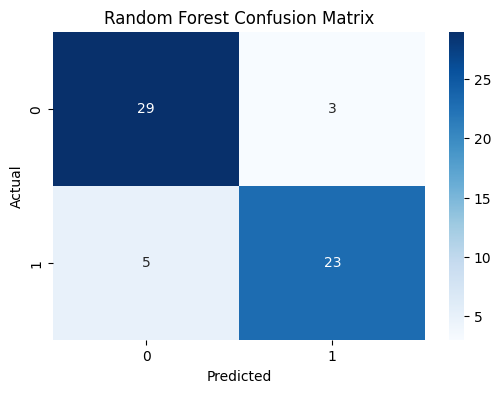

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [11]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)

print('Mean Accuracy:', scores.mean())